# 04 · Statistics & Customer Segmentation

Notebook 03 *showed* that late parcels get worse reviews. Here we **test** it properly, control for other factors, and then turn to
the customer base.

1. Hypothesis tests - is the review gap real, and how big is it?
2. Logistic regression - does lateness still matter after controlling for price, freight, basket size and region?
3. RFM segmentation with k-means
4. Cohort retention

In [1]:
import sys
import warnings
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "src"))   # make the project package importable

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import olist_analysis as oa

oa.set_style()
warnings.filterwarnings("ignore", category=DeprecationWarning)   # library-version noise, not relevant to results
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:,.2f}".format)
from scipy import stats
import statsmodels.formula.api as smf
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

In [2]:
df = oa.load_order_table()
WINDOW = (pd.Timestamp("2017-01-01"), pd.Timestamp("2018-08-31 23:59:59"))
dlv = df[df["order_purchase_timestamp"].between(*WINDOW) & df["is_delivered"]].dropna(subset=["review_score"]).copy()
print(f"Delivered orders with a review: {len(dlv):,}")

Delivered orders with a review: 95,560


## 1 · Hypothesis tests

**H₀:** review scores of late and on-time orders come from the same distribution.
Review scores are ordinal (1-5) and far from normal, so we use the non-parametric **Mann-Whitney U** test and report an
effect size, because with ~95k orders *any* difference will be "significant".

In [3]:
late_scores = dlv.loc[dlv["is_late"] == 1, "review_score"]
ontime_scores = dlv.loc[dlv["is_late"] == 0, "review_score"]

u, p = stats.mannwhitneyu(late_scores, ontime_scores, alternative="less")
rank_biserial = 1 - 2 * u / (len(late_scores) * len(ontime_scores))   # effect size, -1..1
print(f"Mann-Whitney U = {u:,.0f}, p = {p:.2e}")
print(f"Rank-biserial correlation = {rank_biserial:.2f}  (|r| > 0.5 is conventionally a large effect)")
print(f"Median score: late {late_scores.median():.0f} vs on time {ontime_scores.median():.0f}")

Mann-Whitney U = 102,901,002, p = 0.00e+00
Rank-biserial correlation = 0.64  (|r| > 0.5 is conventionally a large effect)
Median score: late 1 vs on time 5


In [4]:
table = pd.crosstab(dlv["is_late"].map({0.0: "on time", 1.0: "late"}),
                    dlv["is_low_review"].map({0.0: "3-5 stars", 1.0: "1-2 stars"}))
chi2, p, dof, _ = stats.chi2_contingency(table)
cramers_v = np.sqrt(chi2 / (table.values.sum() * (min(table.shape) - 1)))
print(f"Chi-square = {chi2:,.0f}, dof = {dof}, p = {p:.2e}, Cramér's V = {cramers_v:.2f}")
table

Chi-square = 15,075, dof = 1, p = 0.00e+00, Cramér's V = 0.40


is_low_review,1-2 stars,3-5 stars
is_late,,
late,3981,2397
on time,8247,80935


In [5]:
rho, p = stats.spearmanr(dlv["distance_km"], dlv["delivery_days"], nan_policy="omit")
print(f"Spearman correlation distance vs delivery days: rho = {rho:.2f}, p = {p:.1e}")

Spearman correlation distance vs delivery days: rho = 0.54, p = 0.0e+00


## 2 · Logistic regression: what predicts a 1-2 star review?

Model: `is_low_review ~ is_late + log(order value) + freight ratio + multi-item + multi-seller + region`.
Coefficients are reported as **odds ratios** (OR > 1 = raises the odds of a bad review).

In [6]:
model_df = dlv.assign(
    low=dlv["is_low_review"].astype(int),
    late=dlv["is_late"].astype(int),
    log_value=np.log1p(dlv["items_value"]),
    freight_ratio_c=dlv["freight_ratio"].clip(upper=2),
    multi_item=(dlv["n_items"] > 1).astype(int),
    multi_seller=(dlv["n_sellers"] > 1).astype(int),
).dropna(subset=["log_value", "freight_ratio_c", "customer_region"])

logit = smf.logit("low ~ late + log_value + freight_ratio_c + multi_item + multi_seller + C(customer_region, Treatment('Southeast'))",
                  data=model_df).fit(disp=False)
ci = logit.conf_int()
odds = pd.DataFrame({"odds_ratio": np.exp(logit.params), "ci_low": np.exp(ci[0]), "ci_high": np.exp(ci[1]),
                     "p_value": logit.pvalues}).drop(index="Intercept")
odds.index = (odds.index.str.replace("C(customer_region, Treatment('Southeast'))[T.", "region: ", regex=False)
                        .str.replace("]", "", regex=False))
print(f"n = {int(logit.nobs):,}   pseudo R² = {logit.prsquared:.3f}")
odds.style.format({"odds_ratio": "{:.2f}", "ci_low": "{:.2f}", "ci_high": "{:.2f}", "p_value": "{:.1e}"})

n = 95,560   pseudo R² = 0.166


,odds_ratio,ci_low,ci_high,p_value
region: Center-West,1.02,0.93,1.12,6.6e-01
region: North,1.10,0.95,1.28,2.2e-01
region: Northeast,1.05,0.98,1.13,1.7e-01
region: South,0.92,0.87,0.98,1.4e-02
late,18.38,17.36,19.46,0.0e+00
log_value,1.15,1.11,1.19,3.3e-16
freight_ratio_c,1.44,1.29,1.60,2.8e-11
multi_item,2.76,2.59,2.94,3.9e-215
multi_seller,3.51,3.10,3.97,1.0e-87


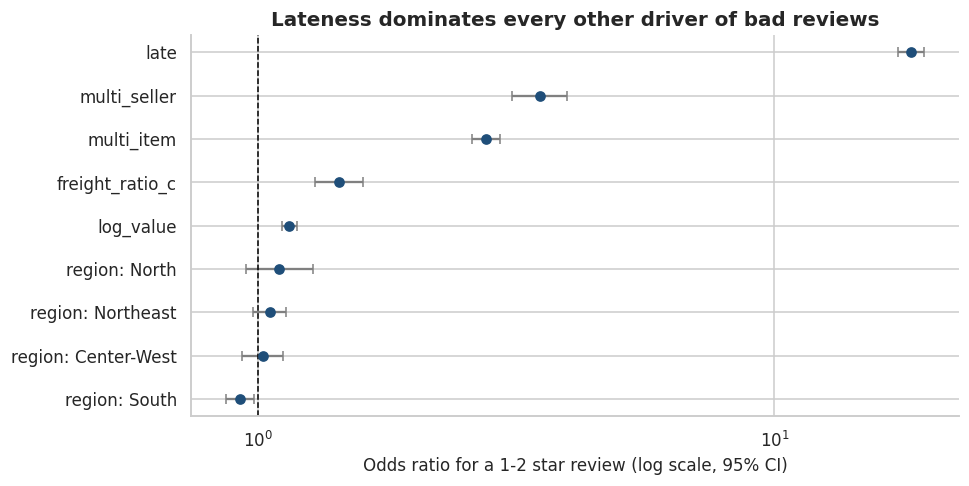

In [7]:
plot = odds.sort_values("odds_ratio")
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.errorbar(plot["odds_ratio"], plot.index, xerr=[plot["odds_ratio"] - plot["ci_low"], plot["ci_high"] - plot["odds_ratio"]],
            fmt="o", color=oa.BASE, ecolor="grey", capsize=3)
ax.axvline(1, color="black", ls="--", lw=1)
ax.set_xscale("log")
ax.set_xlabel("Odds ratio for a 1-2 star review (log scale, 95% CI)")
ax.set_title("Lateness dominates every other driver of bad reviews")
oa.save(fig, "04_odds_ratios")
plt.show()

## 3 · RFM segmentation

In [8]:
cust_orders = df[df["order_purchase_timestamp"].between(*WINDOW) & df["is_delivered"]]
snapshot = (cust_orders["order_purchase_timestamp"].max() + pd.offsets.Day(1)).normalize()
rfm = cust_orders.groupby("customer_unique_id").agg(
    recency_days=("order_purchase_timestamp", lambda s: (snapshot - s.max()).days),
    frequency=("order_id", "count"),
    monetary=("payment_value", "sum"),
)
print(f"{len(rfm):,} unique customers; snapshot date {snapshot:%d %b %Y}")
print(f"Customers with 2+ orders: {(rfm['frequency'] > 1).mean():.1%}")
rfm.describe(percentiles=[.25, .5, .75, .95]).T

93,096 unique customers; snapshot date 30 Aug 2018
Customers with 2+ orders: 3.0%


,count,mean,std,min,25%,50%,75%,95%,max
recency_days,"93,096.00",236.25,150.94,0.00,114.00,218.00,345.00,516.00,601.00
frequency,"93,096.00",1.03,0.21,1.00,1.00,1.00,1.00,1.00,15.00
monetary,"93,096.00",165.15,226.39,9.59,63.03,107.78,182.47,469.14,"13,664.08"


Fewer than 1 in 30 customers ever buys twice - the single most important fact about this customer base. Features are
log-transformed and standardised before clustering because monetary value and frequency are extremely skewed.

In [9]:
X = StandardScaler().fit_transform(np.column_stack([
    rfm["recency_days"], np.log1p(rfm["frequency"]), np.log1p(rfm["monetary"])]))

sample = np.random.default_rng(42).choice(len(X), 20_000, replace=False)
scores = {}
for k in range(2, 7):
    labels = KMeans(n_clusters=k, n_init=10, random_state=42).fit_predict(X)
    scores[k] = silhouette_score(X[sample], labels[sample])
pd.Series(scores, name="silhouette").to_frame().T

,2,3,4,5,6
silhouette,0.32,0.36,0.37,0.35,0.34


In [10]:
K = 4   # highest silhouette score in the search above
rfm["cluster"] = KMeans(n_clusters=K, n_init=10, random_state=42).fit_predict(X)
profile = rfm.groupby("cluster").agg(customers=("frequency", "size"), recency_days=("recency_days", "median"),
                                     avg_orders=("frequency", "mean"), median_spend=("monetary", "median"))

# Name clusters from their profile (robust to label order changing between library versions):
# repeat buyers first; among one-time buyers the oldest are "lapsed"; the rest split by spend.
one_time = profile[profile["avg_orders"] < 1.5]
lapsed_cut = one_time["recency_days"].median()
recent = one_time[one_time["recency_days"] <= lapsed_cut]
spend_cut = recent["median_spend"].median()

def name_cluster(row):
    if row["avg_orders"] >= 1.5:
        return "Repeat buyers"
    if row["recency_days"] > lapsed_cut:
        return "Lapsed one-time buyers"
    return "Recent high spenders" if row["median_spend"] > spend_cut else "Recent low spenders"

profile["segment"] = profile.apply(name_cluster, axis=1)
rfm["segment"] = rfm["cluster"].map(profile["segment"])
profile["share"] = profile["customers"] / profile["customers"].sum()
profile = profile.set_index("segment").sort_values("median_spend", ascending=False)
profile.style.format({"customers": "{:,}", "recency_days": "{:.0f}", "avg_orders": "{:.2f}", "median_spend": "R$ {:,.0f}", "share": "{:.1%}"})

,customers,recency_days,avg_orders,median_spend,share
segment,,,,,
Repeat buyers,"2,789",198,2.11,R$ 226,3.0%
Recent high spenders,"27,547",169,1.00,R$ 212,29.6%
Lapsed one-time buyers,"27,509",413,1.00,R$ 98,29.5%
Recent low spenders,"35,251",144,1.00,R$ 66,37.9%


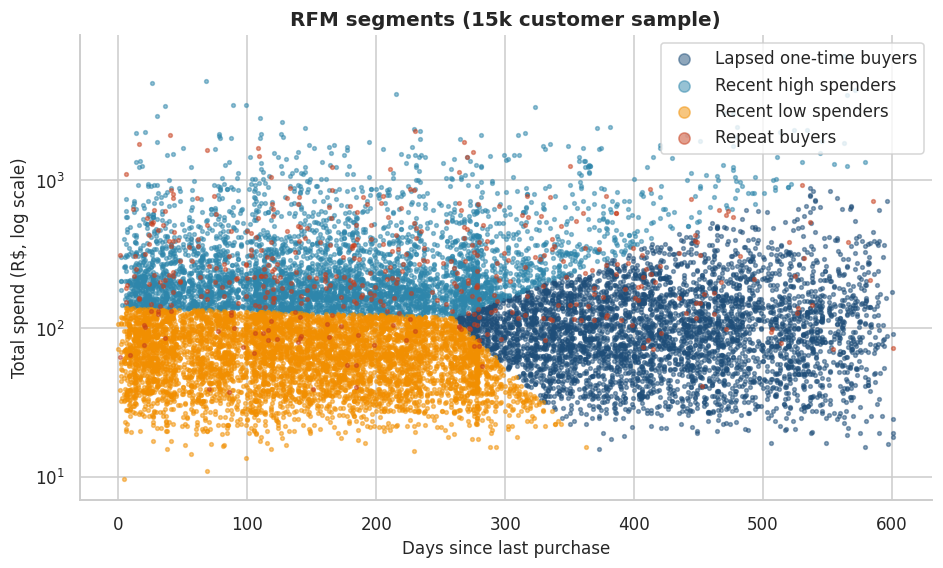

In [11]:
fig, ax = plt.subplots(figsize=(10, 5.5))
for i, (seg, grp) in enumerate(rfm.sample(15_000, random_state=1).groupby("segment")):
    ax.scatter(grp["recency_days"], grp["monetary"], s=6, alpha=0.5, label=seg, color=oa.PALETTE[i])
ax.set_yscale("log")
ax.set_xlabel("Days since last purchase")
ax.set_ylabel("Total spend (R$, log scale)")
ax.set_title("RFM segments (15k customer sample)")
ax.legend(markerscale=3)
oa.save(fig, "04_rfm_segments")
plt.show()

## 4 · Cohort retention

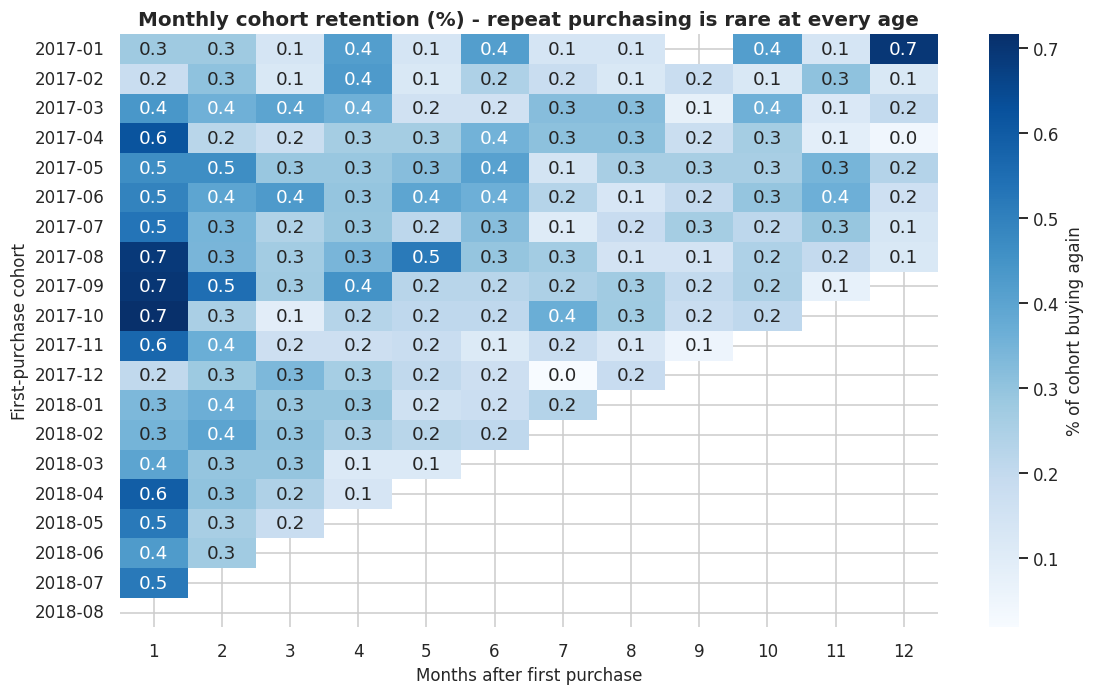

Average month-1 retention: 0.48%


In [12]:
c = cust_orders[["customer_unique_id", "purchase_month"]].copy()
c["cohort"] = c.groupby("customer_unique_id")["purchase_month"].transform("min")
c["months_since"] = ((c["purchase_month"].dt.year - c["cohort"].dt.year) * 12
                     + (c["purchase_month"].dt.month - c["cohort"].dt.month))
cohort_counts = c.drop_duplicates(["customer_unique_id", "months_since"]).pivot_table(
    index="cohort", columns="months_since", values="customer_unique_id", aggfunc="count")
retention = cohort_counts.div(cohort_counts[0], axis=0).loc[:, 1:12]
retention.index = retention.index.strftime("%Y-%m")

fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(retention * 100, annot=True, fmt=".1f", cmap="Blues", ax=ax, cbar_kws={"label": "% of cohort buying again"})
ax.set_xlabel("Months after first purchase")
ax.set_ylabel("First-purchase cohort")
ax.set_title("Monthly cohort retention (%) - repeat purchasing is rare at every age")
oa.save(fig, "04_cohort_retention")
plt.show()
print(f"Average month-1 retention: {retention[1].mean():.2%}")

## Summary

* **Hypothesis test:** late orders have a median review of **1★ vs 5★** on time. Mann-Whitney p < 0.001 with a
  rank-biserial effect size of **0.64** (large) - the gap is real, not an artefact of a big sample. Chi-square agrees (Cramér's V = 0.40).
* **Logistic regression (n = 95,560):** holding basket value, freight ratio, basket composition and region constant, a late delivery
  multiplies the odds of a 1-2★ review by **~18x** (95 % CI 17.4-19.5). Orders split across **several sellers (OR 3.5)** or with
  **several items (OR 2.8)** are the next biggest risk - split shipments arrive at different times.
* **Region stops mattering once lateness is controlled for** (most regional odds ratios include 1): customers in the North-East
  are not harder to please - they simply receive more late parcels.
* **Customers:** 93,096 unique buyers, only **3.0 %** bought more than once and average month-1 retention is **0.5 %**.
  Olist is effectively an acquisition business; k-means (k = 4, best silhouette) separates repeat buyers, recent high and low
  spenders, and lapsed one-time buyers - each needing a different CRM action.

➡️ Next: [05 · Prediction, Forecasting & NLP](05_prediction_forecast_nlp.ipynb)